# EDA Part 2


 > ### 1. Import libraries & loading dataset

In [15]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns 
from datasets import load_dataset
from adjustText import adjust_text

In [16]:
# Loading Dataset
raw = load_dataset('lukebarousse/data_jobs')
print(raw)
df = raw['train'].to_pandas().copy()
df

DatasetDict({
    train: Dataset({
        features: ['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills'],
        num_rows: 785741
    })
})


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


>### 1.2 Data Cleaning

In [17]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else (x))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [18]:
df['job_skills'].head(10)

0                                                  NaN
1           [r, python, sql, nosql, power bi, tableau]
2    [python, sql, c#, azure, airflow, dax, docker,...
3    [python, c++, java, matlab, aws, tensorflow, k...
4    [bash, python, oracle, aws, ansible, puppet, j...
5                                   [python, sql, gcp]
6    [sql, python, java, sql server, gcp, bigquery,...
7    [sql, nosql, gcp, azure, aws, bigquery, databr...
8                        [excel, powerpoint, power bi]
9    [sql, python, r, mongodb, mongodb, sql server,...
Name: job_skills, dtype: object

In [19]:
df_explode =df.explode('job_skills')
df_explode

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,docker,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


>## 2. What are the most in-demand skills for the top three data-related job roles?

In [20]:
df_grp =df_explode.groupby(['job_skills','job_title_short']).size()
df_grp =df_grp.reset_index(name='skill_count').sort_values(by='skill_count',ascending=False)
df_grp

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [21]:
top3 =df['job_title_short'].value_counts().sort_values(ascending=False).head(3).index.to_list()
top3

['Data Analyst', 'Data Engineer', 'Data Scientist']

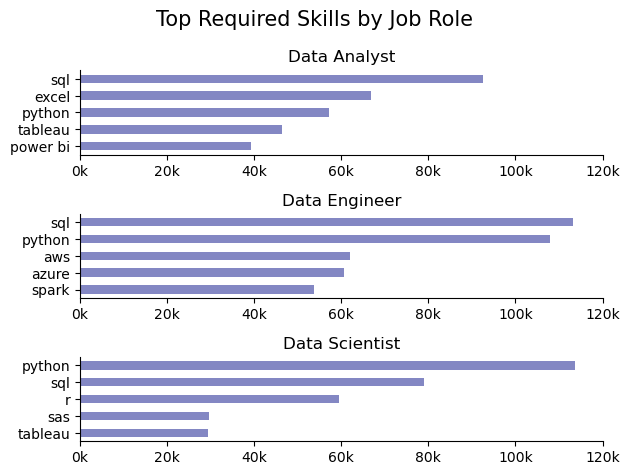

In [22]:
fig, ax = plt.subplots(3,1)
for i,job_title in enumerate(top3):
    df_plot = df_grp[df_grp['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',title=job_title,ax=ax[i],color='#8387c3')
    ax[i].invert_yaxis()

    ax[i].legend().remove()
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,120000)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'{int(x/1000)}k'))
    ax[i].spines[['top','right']].set_visible(False)

fig.suptitle('Top Required Skills by Job Role',fontsize=15)    
fig.tight_layout()


> ## 3. Which data roles have the highest hiring demand? 

In [23]:
df_jobs =df['job_title_short'].value_counts().to_frame().head(3)

In [24]:
df_jobs

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286


In [25]:
df_type =df['job_schedule_type'].value_counts().head(4).to_frame()
df_type

,count
job_schedule_type,
Full-time,701727
Contractor,34793
Internship,8742
Part-time,7881


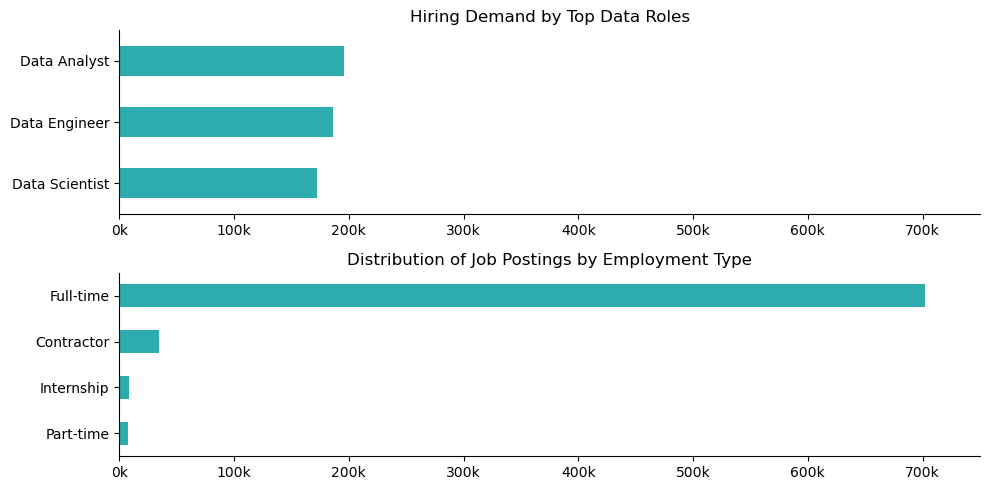

In [26]:
fig, ax = plt.subplots(2, 1,figsize=(10,5))

dfs = [df_jobs, df_type]

for i, data in enumerate(dfs):
    data.plot(kind='barh', ax=ax[i],color='#2cacad')
    ax[i].invert_yaxis()
    ax[i].legend().remove()
    ax[i].set_ylabel('')
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{int(x/1000)}k'))
    ax[i].spines[['top','right']].set_visible(False)
    ax[i].set_xlim(0,750000)
    ax[0].set_title("Hiring Demand by Top Data Roles")
    ax[1].set_title("Distribution of Job Postings by Employment Type")

fig.tight_layout()


> ## 4. What proportion of job postings offer remote work, waive degree requirements, and provide health insurance?

In [27]:
df_pie = df[['job_work_from_home','job_no_degree_mention','job_health_insurance']]
df_pie

,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


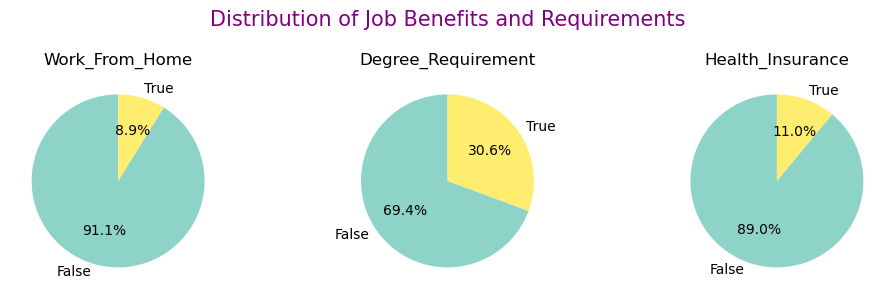

In [28]:
fig, ax = plt.subplots(1,3,figsize=(10,3))
dicts = {'job_work_from_home':'Work_From_Home',
         'job_no_degree_mention':'Degree_Requirement',
         'job_health_insurance':'Health_Insurance'}
for i,(column,title) in enumerate(dicts.items()):
    df_pie[column].value_counts().plot(kind='pie',startangle=90,autopct='%1.1f%%',ax=ax[i],title=title,colormap='Set3')

fig.suptitle('Distribution of Job Benefits and Requirements',fontsize=15,color='purple')
fig.tight_layout()

> ## 5. Is there a relationship between the demand for a skill and its associated salary?

In [55]:
df_scatter =df_explode[df_explode['job_title_short']=='Data Analyst'].groupby('job_skills').agg(skill_count=('job_skills','size'),salary=('salary_year_avg','median'))
df_scatter =df_scatter.sort_values('skill_count',ascending=False).head(10)
df_scatter

,skill_count,salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


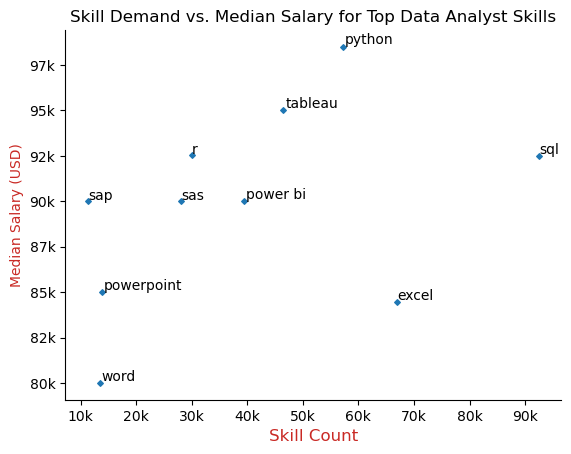

In [94]:
df_scatter.plot(kind='scatter',x='skill_count',y='salary',marker='D',s=8)
axis = plt.gca()
plt.title('Skill Demand vs. Median Salary for Top Data Analyst Skills')
axis.set_ylabel('Median Salary (USD)', color='#C92924')
axis.set_xlabel('Skill Count',fontsize=12,color='#C92924')

axis.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'{int(x/1000)}k'))
axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f'{int(y/1000)}k'))
axis.spines[['top','right']].set_visible(False)


text=[]
for i,txt in enumerate(df_scatter.index):
    text.append(plt.text(df_scatter['skill_count'].iloc[i],df_scatter['salary'].iloc[i],txt))

adjust_text(text,arrowprops=dict(arrowstyle='->',color='grey',lw=1))

plt.show()


> ## 6. What is the distribution of salaries in the dataset?

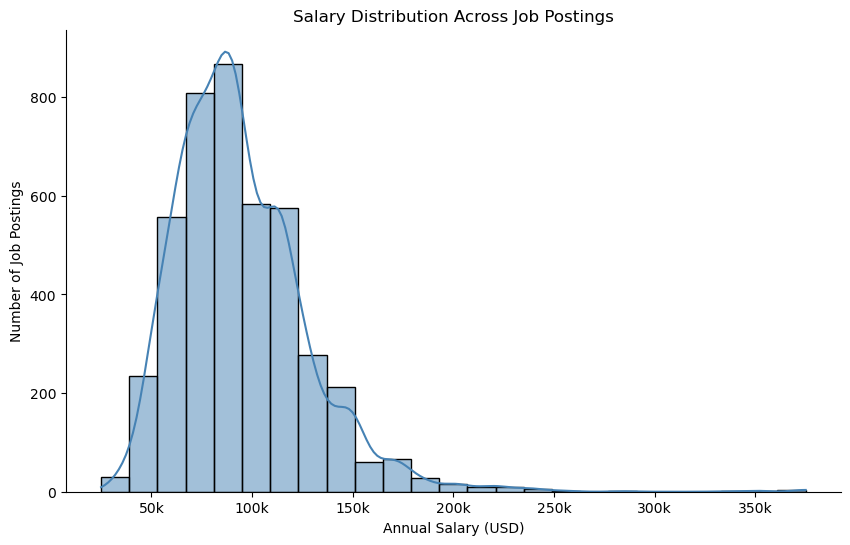

In [118]:
df_hist =df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')]
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_hist,
    x='salary_year_avg',
    bins=25,
    color='steelblue',
    kde=True
)

axis = plt.gca()
axis.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos :f'{int(x/1000)}k'))

plt.title('Salary Distribution Across Job Postings')
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Number of Job Postings")

sns.despine()


In [119]:
job_titles = ['Data Analyst','Data Engineer','Data Scientist']
df_box =df[(df['job_title_short'].isin(job_titles)) & (df['job_country']=='United States')].copy()
df_box.dropna(subset='salary_year_avg',inplace=True)
job_list =[df_box[df_box['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

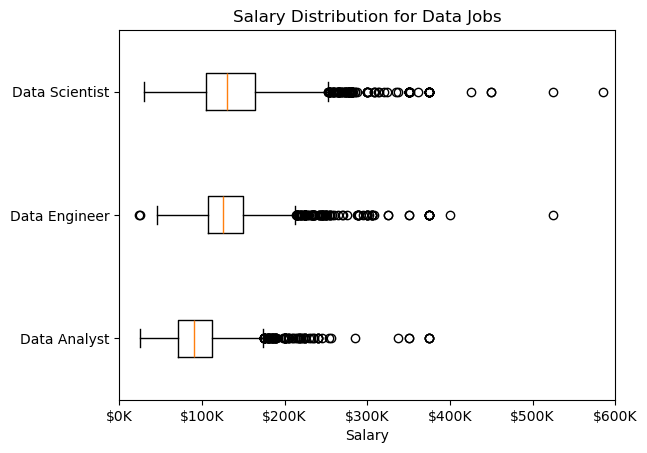

In [124]:
plt.boxplot(job_list,tick_labels=job_titles,vert=False)
plt.title('Salary Distribution for Data Jobs')
plt.xlabel('Salary')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

In [175]:
group = df_explode[df_explode['job_title_short']=='Data Analyst'].groupby('job_skills')['salary_year_avg'].agg(['count','median'])

In [179]:
top_skills =group.sort_values(by='count',ascending=False).head(10).drop(labels='median',axis=1)
top_skills

,count
job_skills,
sql,3079
excel,2135
python,1838
tableau,1657
r,1073
power bi,1042
sas,1006
word,523
powerpoint,518


In [178]:
top_pay=group.sort_values(by='median',ascending=False).head(10)
top_pay

,count,median
job_skills,,
svn,1,400000.0
solidity,1,179000.0
dplyr,3,167500.0
terraform,3,163782.0
gitlab,7,163782.0
couchbase,1,160515.0
datarobot,1,155485.5
golang,2,155000.0
mxnet,2,149000.0


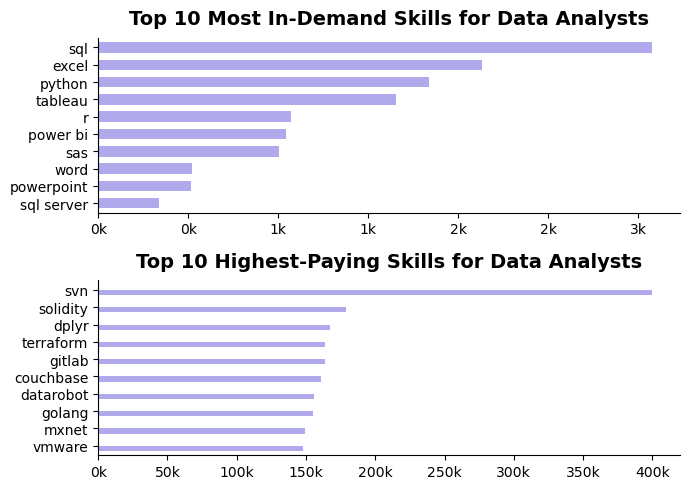

In [180]:
fig, ax = plt.subplots(2, 1, figsize=(7,5))

top = [top_skills, top_pay]
titles = [
    "Top 10 Most In-Demand Skills for Data Analysts",
    "Top 10 Highest-Paying Skills for Data Analysts"
]

for i, (data, title) in enumerate(zip(top, titles)):
    data.plot(
        kind='barh',
        ax=ax[i],
        color="#b0aaec",
        width=0.6          # Adjust bar thickness (default ≈ 0.8)
    )

    ax[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax[i].legend().remove()
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f'{int(x/1000)}k')
    )
    sns.despine()

plt.tight_layout()